**STEP1:IMPORT LIBRARIES**

In [19]:
import pandas as pd
from pandas import Period
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',500)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import plotly 
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**STEP2:IMPORT DATASET**

In [2]:
data = pd.read_csv('/kaggle/input/datasets/oluwanifemiabimbola/mydata/mydata.csv')
df = data.copy()
data.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Gain,Loss,Avg_Gain,Avg_Loss,RSI,SMA,EMA,MACD,Bollinger_Upper,Bollinger_Lower,ROC,PVT,Usd_Eur_Close,Usd_Chf_Close,Usd_Gbp_Close,Usd_Jpy_Close,Usd_Cad_Close,Usd_Inf_Close,Usd_Rub_Close,Usd_Try_Close,IRX_Close,JPM_Close,BAC_Close,Citigroup_Close,WFC_Close,NASDAQ_Close,SP_500_Close,Dow_Jones_Close
0,2005-01-03,44.95,45.44,44.21,44.52,10446500,0,0.0,0.23,0.00,0.572143,0.237143,70.697264,41.697857,42.295957,1.419799,46.563917,36.831798,10.089021,2.579748e+08,0.7424,1.1470,0.5250,102.74,1.2078,4.3548,27.71,1.3440,2.204,26.45,34.03,440.71,19.30,2152.149902,1202.079956,10729.429688
1,2005-01-04,42.67,43.26,41.50,42.14,19418500,0,0.0,0.00,2.38,0.528571,0.407143,56.488550,41.819286,42.275163,1.279141,46.634713,37.003859,2.780488,2.569367e+08,0.7529,1.1676,0.5309,104.34,1.2212,4.3749,27.71,1.3510,2.292,26.18,33.56,436.96,19.31,2107.860107,1188.050049,10630.780273
2,2005-01-05,41.57,42.76,41.56,41.77,8354200,0,0.0,0.00,0.37,0.488571,0.433571,52.982184,41.874286,42.207808,1.124845,46.666939,37.081633,4.294632,2.568634e+08,0.7530,1.1669,0.5304,103.93,1.2244,4.3712,27.86,1.3740,2.282,26.24,33.17,442.44,19.33,2091.239990,1183.739990,10597.830078
3,2005-01-06,41.81,42.25,40.90,41.05,8700900,0,0.0,0.00,0.72,0.488571,0.417143,53.943218,41.945714,42.053433,0.933704,46.650244,37.241185,2.599350,2.567134e+08,0.7585,1.1740,0.5329,104.89,1.2353,4.3834,27.77,1.3925,2.267,26.39,33.12,446.73,19.40,2090.000000,1187.890015,10622.879883
4,2005-01-07,41.38,42.69,41.16,42.32,9836600,0,0.0,1.27,0.00,0.579286,0.414286,58.303379,42.110714,42.088976,0.874620,46.682968,37.538460,8.652118,2.570177e+08,0.7656,1.1841,0.5344,104.89,1.2313,4.3866,27.75,1.3940,2.277,26.17,32.76,444.17,19.38,2088.610107,1186.189941,10603.959961


**STEP3:DATA UNDERSTANDING**

In [3]:
print('\n Data shape')
display(data.shape)

print('\n Data Describe')
display(data.describe())

print('\n Data Info')
display(data.info())

print('\n Data missing info')
display(data.isna().sum())

print('\n Duplicated data')
display(data.duplicated().sum())

print('\n convert the date to datetime')
data['Date'] = pd.to_datetime(data['Date'])


 Data shape


(3552, 36)


 Data Describe


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Gain,Loss,Avg_Gain,Avg_Loss,RSI,SMA,EMA,MACD,Bollinger_Upper,Bollinger_Lower,ROC,PVT,Usd_Eur_Close,Usd_Chf_Close,Usd_Gbp_Close,Usd_Jpy_Close,Usd_Cad_Close,Usd_Inf_Close,Usd_Rub_Close,Usd_Try_Close,IRX_Close,JPM_Close,BAC_Close,Citigroup_Close,WFC_Close,NASDAQ_Close,SP_500_Close,Dow_Jones_Close
count,3552.000000,3552.000000,3552.000000,3552.000000,3.552000e+03,3552.0,3552.0,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3.552000e+03,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000,3552.000000
mean,451.961216,456.560017,446.696306,451.876593,5.899147e+06,0.0,0.0,3.264158,2.769364,3.238215,2.741689,55.190399,448.634385,448.613639,3.603050,471.830518,425.438253,1.810372,3.205454e+08,0.792430,1.026021,0.641412,103.090075,1.150203,3.809871,40.687773,2.345183,1.182281,49.854372,20.697368,127.266624,33.261090,3832.766929,1699.743803,15258.949719
std,527.550229,532.249029,521.588087,527.147584,5.050525e+06,0.0,0.0,8.715350,8.704835,4.208787,4.469360,17.035607,523.898711,523.689712,13.142688,549.877364,498.623365,8.420355,3.314393e+07,0.077234,0.116566,0.087546,13.388047,0.128851,0.298263,16.029596,1.252232,1.562576,26.615220,10.813620,154.523054,12.712179,1864.763197,577.426442,5059.060804
min,26.090000,26.300000,25.760000,26.070000,9.844000e+05,0.0,0.0,0.000000,0.000000,0.042143,0.017857,7.383321,26.550714,27.564424,-82.597643,27.306185,21.911581,-37.386443,2.341648e+08,0.625500,0.722800,0.474300,75.740000,0.918700,3.214000,0.716200,1.142300,0.003000,12.460000,2.850000,9.480000,6.280000,1268.640015,676.530029,6547.049805
25%,80.632500,82.045000,78.987500,80.587500,3.246125e+06,0.0,0.0,0.000000,0.000000,0.860536,0.659107,42.393712,80.528750,80.322997,-0.664519,86.256752,74.400237,-2.995318,3.029647e+08,0.735650,0.945975,0.593900,92.966750,1.027075,3.590550,28.523375,1.485075,0.055000,31.227500,12.670000,39.690000,22.027500,2333.947510,1244.662445,11224.214844
50%,230.985000,234.645000,227.990000,231.700000,4.770600e+06,0.0,0.0,0.100000,0.000000,1.616429,1.372857,55.234208,228.506786,228.476101,1.574398,243.248970,214.693585,1.652870,3.361765e+08,0.777100,0.991000,0.636000,106.323000,1.126850,3.760000,31.658400,1.798300,0.205000,36.635000,15.760000,49.420000,27.160000,2989.119995,1478.960022,13426.345215
75%,618.190000,626.755000,610.015000,617.777500,6.999700e+06,0.0,0.0,2.782500,1.990000,3.641250,2.719286,67.350388,607.345357,609.204782,6.016151,649.581692,567.082258,6.043692,3.435742e+08,0.860225,1.092325,0.695125,113.190250,1.276000,3.929025,58.330250,2.920550,2.090000,58.905000,29.665000,73.002500,46.042500,5008.377563,2092.529968,17904.755371
max,2038.110000,2050.500000,2013.000000,2039.510000,1.043292e+08,0.0,0.0,128.520000,139.360000,30.065714,43.907857,97.365648,1992.156429,1979.379425,62.493688,2099.471495,1951.978058,50.696111,3.481716e+08,0.962400,1.324800,0.831800,125.629000,1.456300,4.733800,82.900000,6.953300,5.045000,116.830000,43.480000,519.080000,62.180000,8330.209961,3025.860107,27359.160156



 Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             3552 non-null   object 
 1   Open             3552 non-null   float64
 2   High             3552 non-null   float64
 3   Low              3552 non-null   float64
 4   Close            3552 non-null   float64
 5   Volume           3552 non-null   int64  
 6   Dividends        3552 non-null   int64  
 7   Stock Splits     3552 non-null   float64
 8   Gain             3552 non-null   float64
 9   Loss             3552 non-null   float64
 10  Avg_Gain         3552 non-null   float64
 11  Avg_Loss         3552 non-null   float64
 12  RSI              3552 non-null   float64
 13  SMA              3552 non-null   float64
 14  EMA              3552 non-null   float64
 15  MACD             3552 non-null   float64
 16  Bollinger_Upper  3552 non-null   float64
 17  Bo

...


 Data missing info


Date               0
Open               0
High               0
Low                0
Close              0
Volume             0
Dividends          0
Stock Splits       0
Gain               0
Loss               0
Avg_Gain           0
Avg_Loss           0
RSI                0
SMA                0
EMA                0
MACD               0
Bollinger_Upper    0
Bollinger_Lower    0
ROC                0
PVT                0
Usd_Eur_Close      0
Usd_Chf_Close      0
Usd_Gbp_Close      0
Usd_Jpy_Close      0
Usd_Cad_Close      0
Usd_Inf_Close      0
Usd_Rub_Close      0
Usd_Try_Close      0
IRX_Close          0
JPM_Close          0
BAC_Close          0
Citigroup_Close    0
WFC_Close          0
NASDAQ_Close       0
SP_500_Close       0
Dow_Jones_Close    0
dtype: int64


 Duplicated data


np.int64(0)


 convert the date to datetime


**STEP4: EXPLONATORY DATA ANALYSIS**

In [4]:
#correlation 
corr = data.corr()
corr

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Gain,Loss,Avg_Gain,Avg_Loss,RSI,SMA,EMA,MACD,Bollinger_Upper,Bollinger_Lower,ROC,PVT,Usd_Eur_Close,Usd_Chf_Close,Usd_Gbp_Close,Usd_Jpy_Close,Usd_Cad_Close,Usd_Inf_Close,Usd_Rub_Close,Usd_Try_Close,IRX_Close,JPM_Close,BAC_Close,Citigroup_Close,WFC_Close,NASDAQ_Close,SP_500_Close,Dow_Jones_Close
Date,1.000000,0.839881,0.839852,0.840167,0.840037,-0.341803,NaN,NaN,0.342557,0.290784,0.703040,0.559891,0.092025,0.839580,0.839831,0.261005,0.838405,0.839690,-0.006647,0.846162,0.636795,-0.690332,0.854709,0.133260,0.530527,-0.620731,0.856659,0.854055,-0.428597,0.856374,-0.291537,-0.688908,0.888764,0.911296,0.872591,0.879106
Open,0.839881,1.000000,0.999922,0.999871,0.999795,-0.206937,NaN,NaN,0.407910,0.362930,0.853033,0.677006,0.106943,0.999012,0.999324,0.331601,0.998300,0.998389,0.005387,0.539170,0.614815,-0.334084,0.779412,0.286906,0.655320,-0.411605,0.808624,0.979937,0.003398,0.965557,0.134342,-0.343502,0.788655,0.950077,0.913793,0.936103
High,0.839852,0.999922,1.000000,0.999844,0.999896,-0.205054,NaN,NaN,0.415382,0.360979,0.855416,0.679862,0.106763,0.999087,0.999396,0.328847,0.998515,0.998309,0.005339,0.539276,0.614308,-0.334274,0.779096,0.286703,0.655178,-0.411593,0.808657,0.980104,0.003475,0.965482,0.134120,-0.343719,0.788439,0.949873,0.913514,0.935959
Low,0.840167,0.999871,0.999844,1.000000,0.999909,-0.209516,NaN,NaN,0.411209,0.352262,0.851639,0.671991,0.110007,0.998780,0.999118,0.335083,0.997905,0.998336,0.007725,0.539312,0.615721,-0.334066,0.780011,0.287104,0.655606,-0.411642,0.808800,0.979819,0.003083,0.965792,0.134404,-0.343495,0.789258,0.950621,0.914389,0.936522
Close,0.840037,0.999795,0.999896,0.999909,1.000000,-0.207305,NaN,NaN,0.419061,0.350537,0.853887,0.675302,0.109345,0.998899,0.999223,0.332066,0.998176,0.998288,0.007353,0.539341,0.614977,-0.334215,0.779574,0.286795,0.655403,-0.411673,0.808723,0.979914,0.003260,0.965715,0.134293,-0.343634,0.788924,0.950340,0.914027,0.936315
Volume,-0.341803,-0.206937,-0.205054,-0.209516,-0.207305,1.000000,NaN,NaN,0.043641,0.063014,-0.098775,-0.033209,-0.037719,-0.204928,-0.205186,-0.124783,-0.199333,-0.210809,0.048000,-0.292200,-0.252523,0.323250,-0.271526,0.014593,-0.099917,0.181050,-0.252857,-0.217562,0.232596,-0.220749,0.197112,0.265122,-0.310522,-0.283630,-0.277942,-0.269174
Dividends,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stock Splits,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gain,0.342557,0.407910,0.415382,0.411209,0.419061,0.043641,NaN,NaN,1.000000,-0.119187,0.483680,0.375140,0.086108,0.409281,0.409480,0.015626,0.414859,0.402552,0.054243,0.223869,0.231665,-0.142968,0.303527,0.114194,0.267049,-0.165272,0.336483,0.404033,0.008533,0.398412,0.054757,-0.143852,0.321105,0.387032,0.369515,0.383226
Loss,0.290784,0.362930,0.360979,0.352262,0.350537,0.063014,NaN,NaN,-0.119187,1.000000,0.343569,0.508004,-0.146575,0.371850,0.370528,-0.066887,0.377138,0.365494,-0.145353,0.184680,0.192997,-0.116638,0.261851,0.093248,0.225328,-0.141225,0.285114,0.364885,0.016741,0.329387,0.039077,-0.123367,0.245873,0.313881,0.298884,0.313552


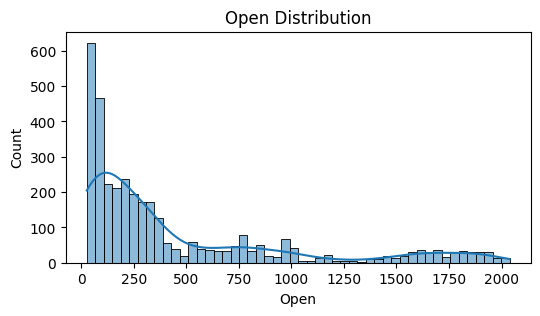

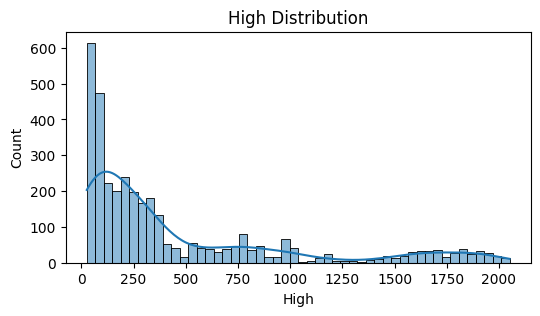

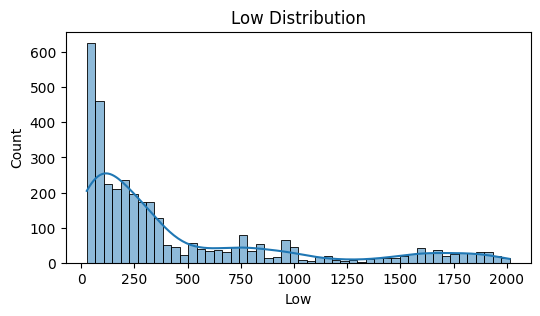

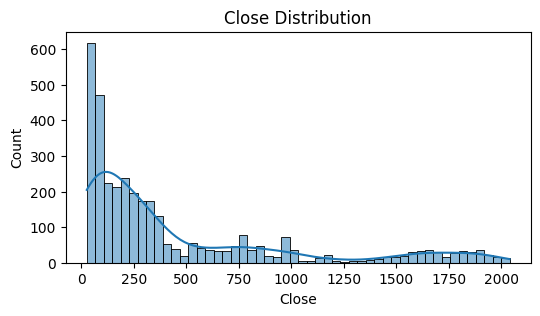

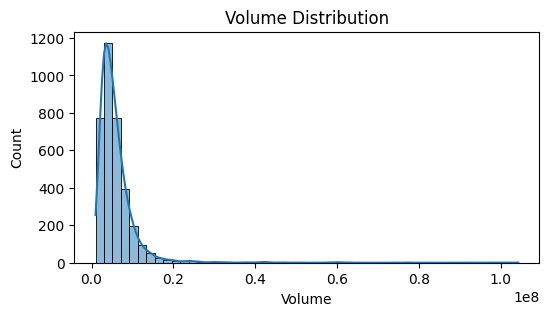

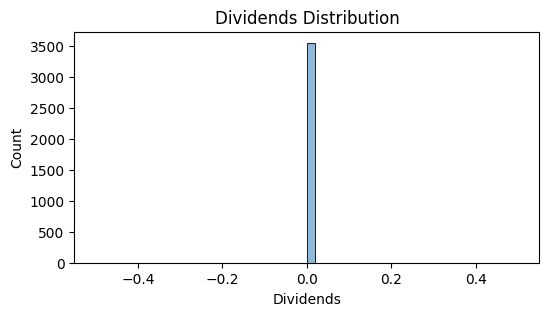

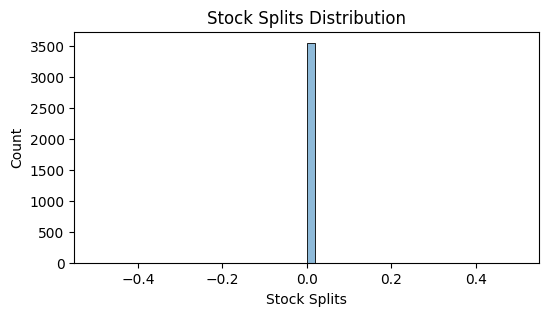

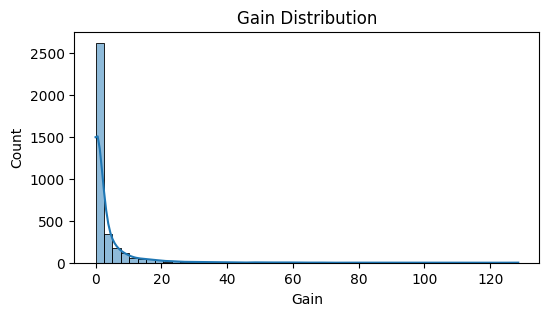

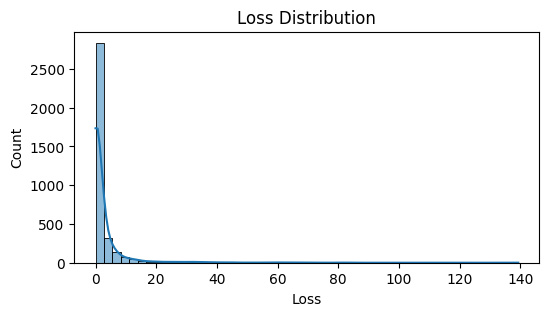

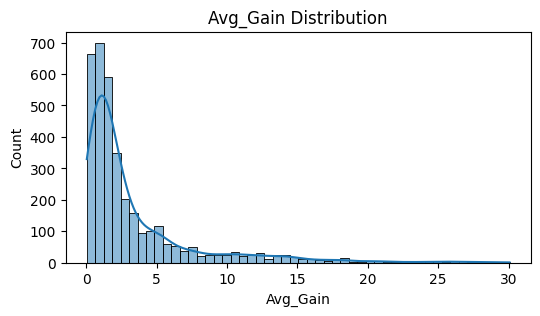

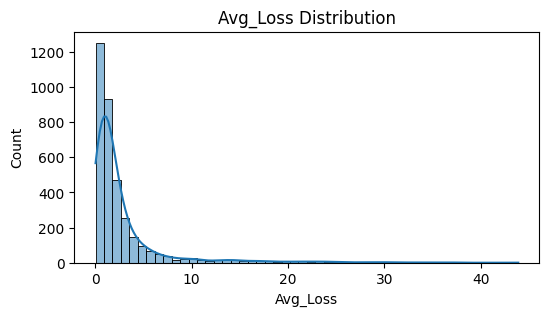

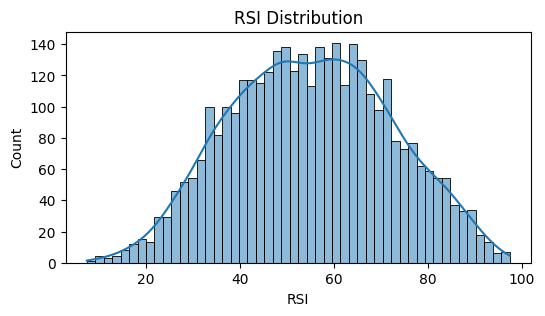

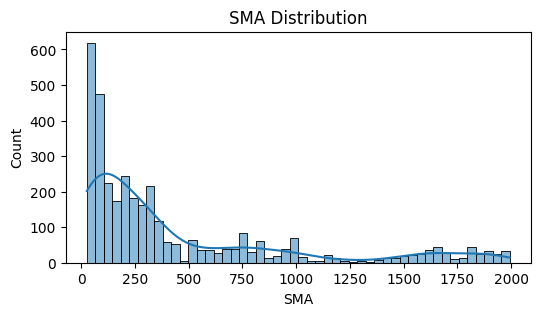

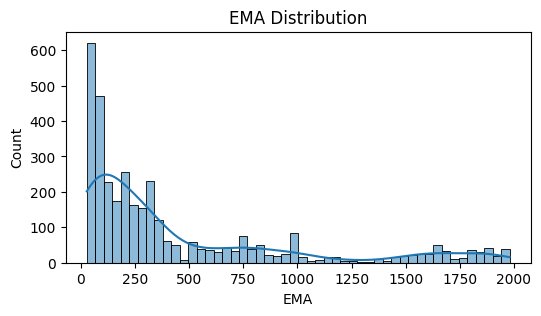

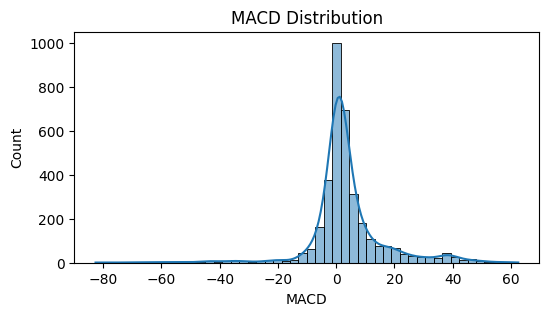

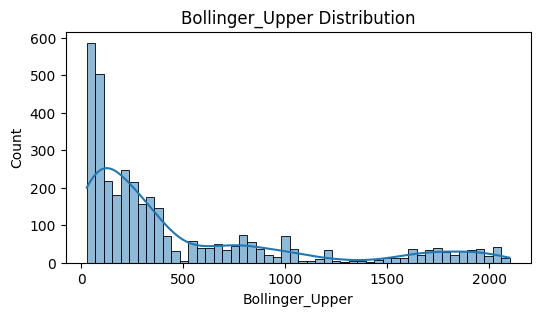

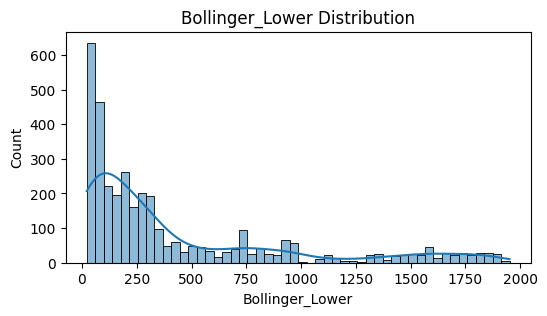

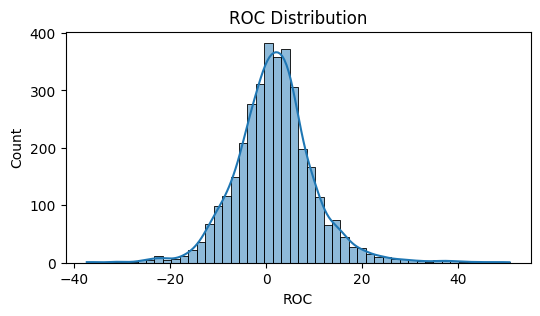

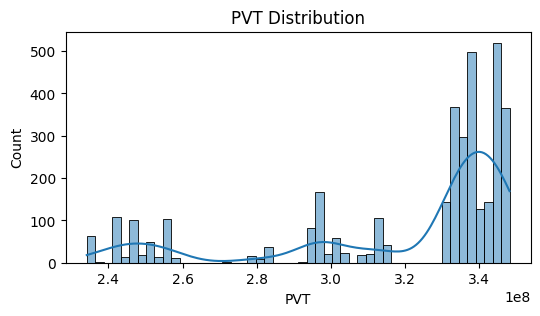

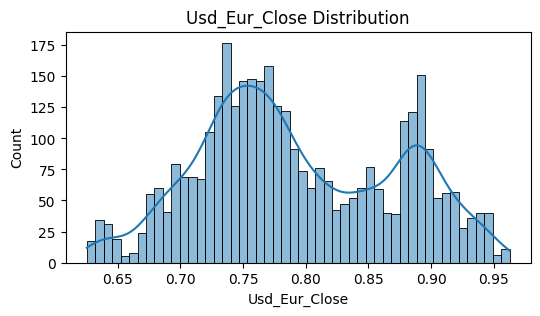

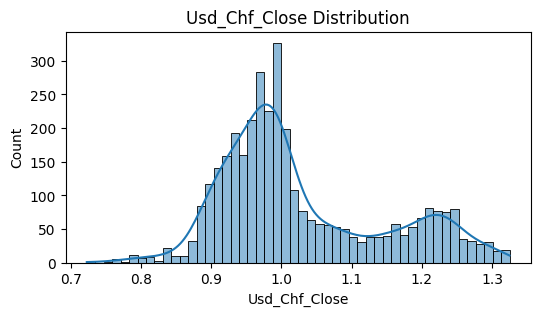

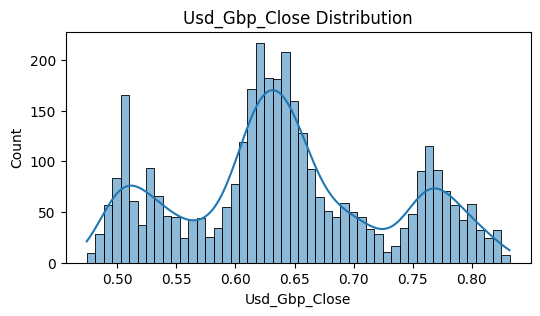

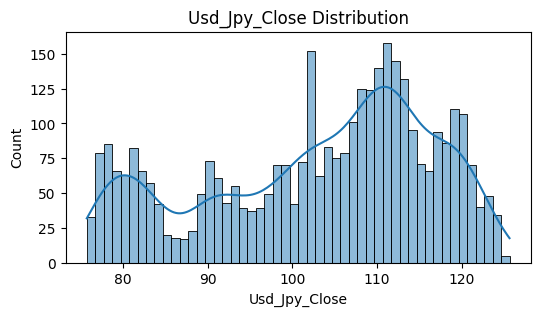

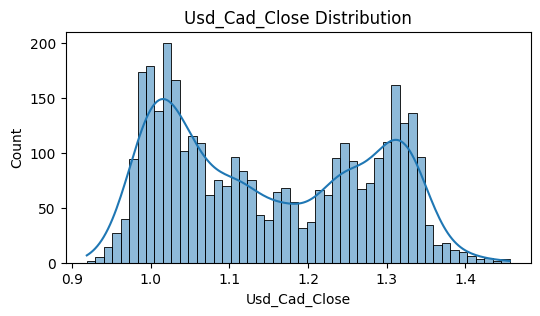

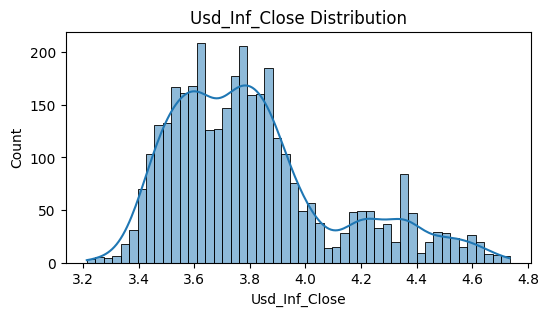

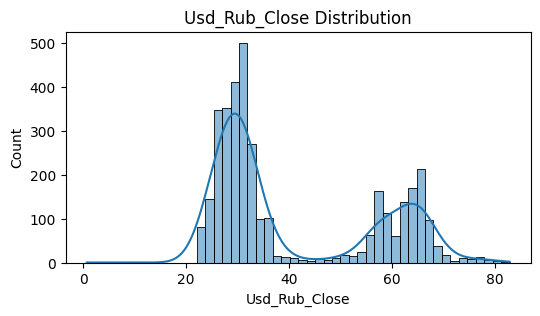

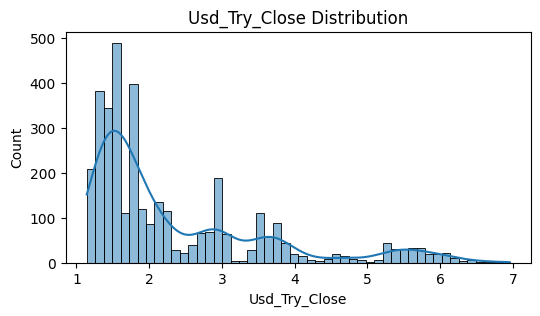

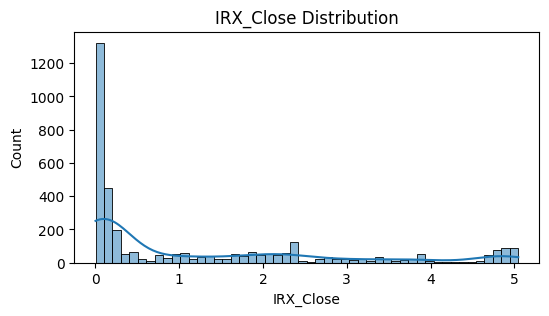

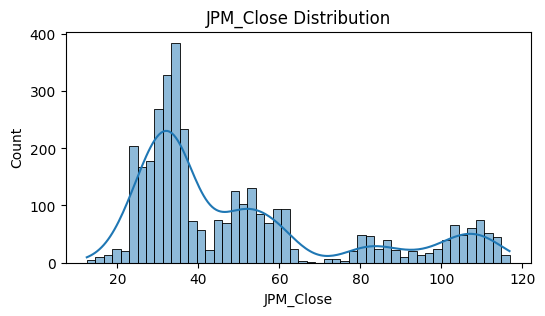

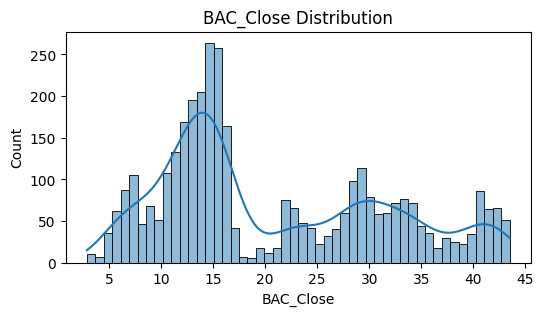

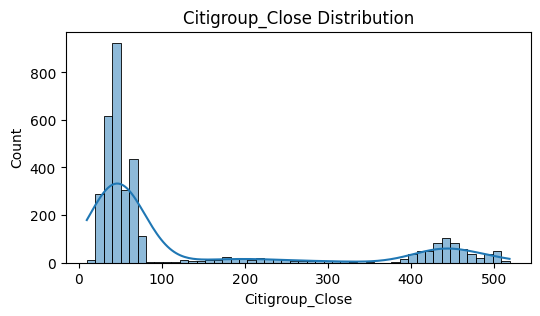

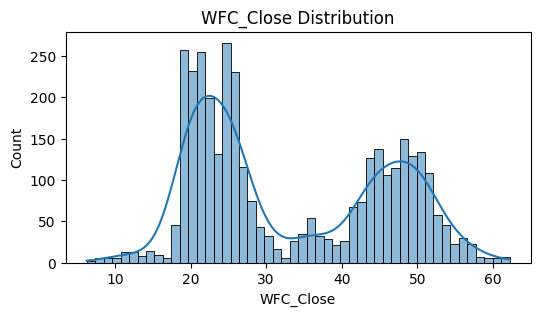

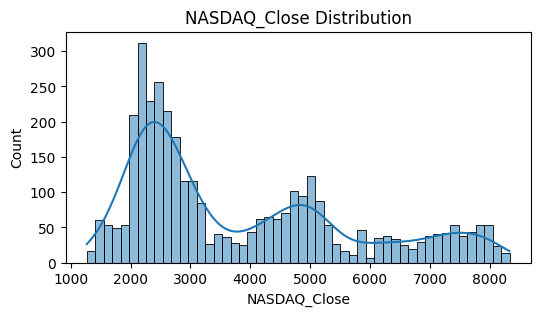

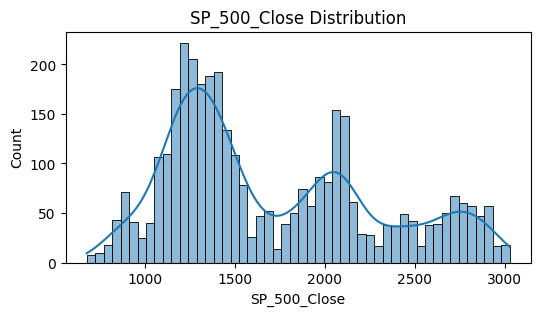

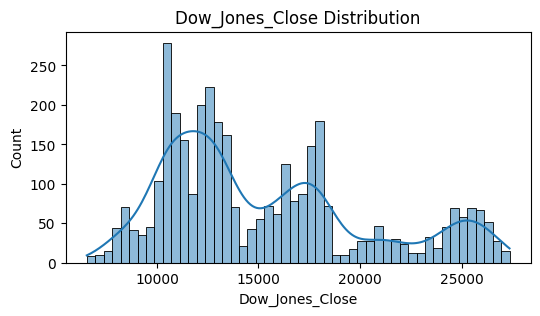

In [5]:
#data distribution of the features
numerical_column = data.select_dtypes(include='number')
for col in numerical_column:
    plt.figure(figsize=(6,3))
    sns.histplot(data[col].dropna(), kde=True, bins=50)
    plt.title(f'{col} Distribution')
    plt.show()

In [6]:
#data skew and kurtosis
print('\n Data skew')
display(numerical_column.skew())
print('\n Data Kurtosis')
display(numerical_column.kurtosis())


 Data skew


Open               1.572808
High               1.573248
Low                1.571012
Close              1.571837
Volume             6.658092
Dividends          0.000000
Stock Splits       0.000000
Gain               6.373445
Loss               6.954719
Avg_Gain           2.607297
Avg_Loss           3.980854
RSI                0.020048
SMA                1.579890
EMA                1.577876
MACD              -0.149591
Bollinger_Upper    1.588647
Bollinger_Lower    1.578238
ROC                0.485252
PVT               -1.408430
Usd_Eur_Close      0.197418
Usd_Chf_Close      0.771657
Usd_Gbp_Close      0.168933
Usd_Jpy_Close     -0.499687
Usd_Cad_Close      0.188187
Usd_Inf_Close      0.937321
Usd_Rub_Close      0.714873
Usd_Try_Close      1.515742
IRX_Close          1.244568
JPM_Close          1.174000
BAC_Close          0.547732
Citigroup_Close    1.513239
WFC_Close          0.317887
NASDAQ_Close       0.831401
SP_500_Close       0.604659
Dow_Jones_Close    0.776255
dtype: float64


 Data Kurtosis


Open                1.363756
High                1.361001
Low                 1.361834
Close               1.359825
Volume             79.924352
Dividends           0.000000
Stock Splits        0.000000
Gain               58.946891
Loss               64.417071
Avg_Gain            7.875965
Avg_Loss           19.310675
RSI                -0.590212
SMA                 1.392351
EMA                 1.381907
MACD                7.400796
Bollinger_Upper     1.412691
Bollinger_Lower     1.411692
ROC                 3.295105
PVT                 0.591588
Usd_Eur_Close      -0.870030
Usd_Chf_Close      -0.327459
Usd_Gbp_Close      -0.704835
Usd_Jpy_Close      -0.873991
Usd_Cad_Close      -1.411354
Usd_Inf_Close       0.316809
Usd_Rub_Close      -1.181783
Usd_Try_Close       1.517621
IRX_Close           0.263549
JPM_Close           0.131860
BAC_Close          -0.949581
Citigroup_Close     0.516413
WFC_Close          -1.400821
NASDAQ_Close       -0.507508
SP_500_Close       -0.748146
Dow_Jones_Clos

In [7]:
#checking the data outlier 
for col in numerical_column:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = data[(data[col] < q1 - 1.5*iqr) | (data[col] > q3 + 1.5*iqr)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(data):.2%})")

Open: 380 outliers (10.70%)
High: 382 outliers (10.75%)
Low: 373 outliers (10.50%)
Close: 379 outliers (10.67%)
Volume: 178 outliers (5.01%)
Dividends: 0 outliers (0.00%)
Stock Splits: 0 outliers (0.00%)
Gain: 440 outliers (12.39%)
Loss: 452 outliers (12.73%)
Avg_Gain: 384 outliers (10.81%)
Avg_Loss: 353 outliers (9.94%)
RSI: 0 outliers (0.00%)
SMA: 385 outliers (10.84%)
EMA: 380 outliers (10.70%)
MACD: 555 outliers (15.62%)
Bollinger_Upper: 377 outliers (10.61%)
Bollinger_Lower: 386 outliers (10.87%)
ROC: 143 outliers (4.03%)
PVT: 64 outliers (1.80%)
Usd_Eur_Close: 0 outliers (0.00%)
Usd_Chf_Close: 22 outliers (0.62%)
Usd_Gbp_Close: 0 outliers (0.00%)
Usd_Jpy_Close: 0 outliers (0.00%)
Usd_Cad_Close: 0 outliers (0.00%)
Usd_Inf_Close: 181 outliers (5.10%)
Usd_Rub_Close: 0 outliers (0.00%)
Usd_Try_Close: 264 outliers (7.43%)
IRX_Close: 0 outliers (0.00%)
JPM_Close: 393 outliers (11.06%)
BAC_Close: 0 outliers (0.00%)
Citigroup_Close: 839 outliers (23.62%)
WFC_Close: 0 outliers (0.00%)
NAS

**DATAFEATURE**

In [8]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['DayOfWeek'] = data['Date'].dt.dayofweek  

In [9]:
#data
X= data.drop(['Close', 'Date'],axis=1)
y= data['Close']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=False)

In [10]:
new_data = data[['Date','Close']]
new_data = new_data.rename(columns={'Date':'ds','Close':'y'})
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      3552 non-null   datetime64[ns]
 1   y       3552 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 55.6 KB


In [25]:
def timeseries(data, X_train, y_train, X_test, periods=30):
    #XGBoost
    xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=300,
                              max_depth=5, learning_rate=0.05)
    xgb_model.fit(X_train, y_train)

    #Random Forest
    regr = RandomForestRegressor(max_depth=2, random_state=0)
    regr.fit(X_train, y_train)

    #split
    train_size = len(X_train)
    close_train = data['Close'].iloc[:train_size]

    #Arima
    res = ARIMA(close_train, order=(1, 0, 0)).fit()

    #SARIMAX
    ress = SARIMAX(close_train, order=(1, 0, 0)).fit(disp=False)

    #Prophet: fit on train only
    train_data_for_prophet = data.iloc[:train_size][['Date', 'Close']].rename(
        columns={'Date': 'ds', 'Close': 'y'})
    model = Prophet()
    model.fit(train_data_for_prophet)
    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    return xgb_model, regr, res, ress, model, forecast

In [27]:
#evaluate 
X = data.drop(['Close', 'Date'], axis=1)
y = data['Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, shuffle=False)

xgb_model, regr, res, ress, model, forecast = timeseries(
    data, X_train, y_train, X_test, periods=len(y_test)
)

eval_results = evaluate_five_models(
    y_true=y_test,
    X_test=X_test,
    xgb_model=xgb_model,
    regr=regr,
    res=res,
    ress=ress,
    model=model,
    forecast=forecast,
    periods=len(y_test)
)
print(eval_results)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
18:29:23 - cmdstanpy - INFO - Chain [1] start processing
18:29:24 - cmdstanpy - INFO - Chain [1] done processing


               RMSE         MAE   MAPE (%)        R2
prophet  795.297785  635.732502  50.731676 -1.336577
xgb      837.404208  660.150567  51.301624 -1.590543
rf       896.976174  731.868771  59.762801 -1.972229
sarimax  954.504003  789.509965  65.605380 -2.365704
arima    960.668418  795.643378  66.210572 -2.409318
